In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", iris.target_names)

Dataset shape: (150, 4)
Target shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("First training sample:")
print(X_train[0])

First training sample:
[-1.72156775 -0.33210111 -1.34572231 -1.32327558]


In [8]:
def one_hot_encode(y, num_classes):
    one_hot = np.zeros((len(y), num_classes))
    one_hot[np.arange(len(y)), y] = 1
    return one_hot


y_train_encoded = one_hot_encode(y_train, 3)
y_test_encoded = one_hot_encode(y_test, 3)

print(y_train_encoded[:5])

[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [9]:
def relu(x):
    return np.maximum(0, x)
def relu_derivative(x):
    return (x > 0).astype(float)

In [10]:
def softmax(x):
    exp_values = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)

In [11]:
def cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-12
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    loss = -np.sum(y_true * np.log(y_pred)) / len(y_true)

    return loss

In [12]:
np.random.seed(42)

input_size = 4
hidden_size = 8
output_size = 3

W1 = np.random.randn(input_size, hidden_size) * 0.01
W2 = np.random.randn(hidden_size, output_size) * 0.01

b1 = np.zeros((1, hidden_size))
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)

W1 shape: (4, 8)
W2 shape: (8, 3)


In [13]:
def forward_pass(X):

    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

In [14]:
def backward_pass(X, y, Z1, A1, A2):

    m = X.shape[0]
    dZ2 = A2 - y

    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = np.dot(dZ2, W2.T)

    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2

In [15]:
def update_parameters(dW1, db1, dW2, db2, learning_rate):

    global W1, b1, W2, b2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

In [16]:
epochs = 5000
learning_rate = 0.01

loss_history = []

for epoch in range(epochs):

    Z1, A1, Z2, A2 = forward_pass(X_train)

    loss = cross_entropy_loss(y_train_encoded, A2)

    dW1, db1, dW2, db2 = backward_pass(X_train, y_train_encoded, Z1, A1, A2)

    update_parameters(dW1, db1, dW2, db2, learning_rate)

    loss_history.append(loss)

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 1.0987
Epoch 500, Loss: 1.0859
Epoch 1000, Loss: 0.5927
Epoch 1500, Loss: 0.3693
Epoch 2000, Loss: 0.2749
Epoch 2500, Loss: 0.2154
Epoch 3000, Loss: 0.1724
Epoch 3500, Loss: 0.1409
Epoch 4000, Loss: 0.1185
Epoch 4500, Loss: 0.1027


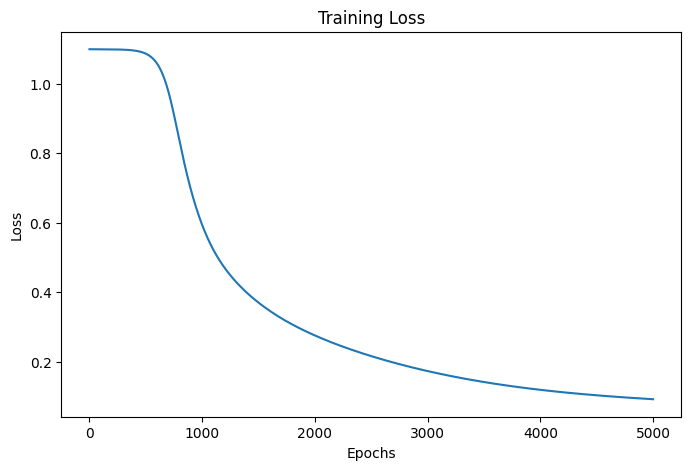

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

In [18]:
def predict(X):

    _, _, _, output = forward_pass(X)

    predictions = np.argmax(output, axis=1)

    return predictions

In [19]:
y_pred = predict(X_test)

print("Predicted:", y_pred)
print("Actual:   ", y_test)

Predicted: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]
Actual:    [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


In [20]:
accuracy = np.mean(y_pred == y_test)

print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 96.67%
